In [1]:
import os
import pandas as pd
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import shutil

device = "cuda" if torch.cuda.is_available() else "cpu"
IMAGES_DIR = r"C:\Users\Lenovo\Internship\data\Flickr8k\images"
SAVE_DIR = r"C:\Users\Lenovo\Internship\data\xai_examples"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_dir = r"C:\Users\Lenovo\Internship\models\week2_baseline_blip"
processor = BlipProcessor.from_pretrained(baseline_dir)
model = BlipForConditionalGeneration.from_pretrained(baseline_dir).to(device)
model.eval()

print("Baseline model loaded.")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Baseline model loaded.


In [2]:
captions_df = pd.read_csv(
    r"C:\Users\Lenovo\Internship\data\Flickr8k\captions.txt",
    sep="|"
)

from sklearn.model_selection import train_test_split
unique_images = captions_df["image_name"].unique()
train_images, val_images = train_test_split(unique_images, test_size=0.1, random_state=42)
val_df = captions_df[captions_df["image_name"].isin(val_images)].reset_index(drop=True)

print("Val images available:", val_df["image_name"].nunique())

Val images available: 810


In [3]:
smoothie = SmoothingFunction().method4

# group so each image has all its ground-truth captions together
grouped = val_df.groupby("image_name")["caption_text"].apply(list).reset_index()
grouped = grouped.sample(n=60, random_state=42)  # sample a pool to evaluate, then pick best/worst from it

results = []
for _, row in grouped.iterrows():
    img_name = row["image_name"]
    gt_captions = row["caption_text"]  # list of ground truth captions

    image = Image.open(os.path.join(IMAGES_DIR, img_name)).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, num_beams=3, max_new_tokens=25)
    generated = processor.decode(out[0], skip_special_tokens=True)

    ref_tokens_list = [gt.lower().split() for gt in gt_captions]
    bleu = sentence_bleu(ref_tokens_list, generated.lower().split(), smoothing_function=smoothie)

    results.append({
        "image_name": img_name,
        "generated_caption": generated,
        "ground_truth_captions": gt_captions,
        "bleu": bleu
    })

results_df = pd.DataFrame(results).sort_values("bleu", ascending=False)
print(results_df[["image_name", "generated_caption", "bleu"]])

                   image_name  \
59  3457572788_e1fe4f6480.jpg   
42  2795287622_da187a3e86.jpg   
13   977856234_0d9caee7b2.jpg   
57   197142902_f05ff198c2.jpg   
21   162743064_bb242faa31.jpg   
52  3475581086_a533567561.jpg   
24   136644885_f7d2bbf546.jpg   
14  2674784195_704f6b79d0.jpg   
12  3170110692_d1e0e66cee.jpg   
39  2428751994_88a6808246.jpg   
9   3439243433_d5f3508612.jpg   
47  3700004668_99c3e3f55b.jpg   
11  2583001715_1ce6f58942.jpg   
6   2447289477_e888df561d.jpg   
26   446138054_d40c66d5f0.jpg   
16  2863180332_372510aa49.jpg   
41  3320411267_df70b90501.jpg   
8   2875528143_94d9480fdd.jpg   
2   2563578471_9a4e4c2ecc.jpg   
33   436009777_440c7679a1.jpg   
44  3562169000_6aa7f1043d.jpg   
56  3396036947_0af6c3aab7.jpg   
50  2924870944_90ff9eca1a.jpg   
30   361183669_52be9662b9.jpg   
45  2512876666_9da03f9589.jpg   
49  3440724965_03d6ca5399.jpg   
28  2505465055_f1e6cf9b76.jpg   
25  1299459562_ed0e064aee.jpg   
48  3373946160_1c82d54442.jpg   
53  364040

In [4]:
n_good = 6
n_poor = 6

good_examples = results_df.head(n_good)   # highest BLEU = good captions
poor_examples = results_df.tail(n_poor)   # lowest BLEU = poor captions

selected = pd.concat([good_examples, poor_examples]).reset_index(drop=True)
selected["quality_label"] = ["good"] * n_good + ["poor"] * n_poor

print(selected[["image_name", "generated_caption", "bleu", "quality_label"]])

                   image_name  \
0   3457572788_e1fe4f6480.jpg   
1   2795287622_da187a3e86.jpg   
2    977856234_0d9caee7b2.jpg   
3    197142902_f05ff198c2.jpg   
4    162743064_bb242faa31.jpg   
5   3475581086_a533567561.jpg   
6   3364160101_c5e6c52b25.jpg   
7   3560081723_62da0035bd.jpg   
8   1598085252_f3219b6140.jpg   
9    181103691_fb2f956abd.jpg   
10  3084034954_fe5737197d.jpg   
11  1564614124_0ee6799935.jpg   

                                    generated_caption      bleu quality_label  
0                     a man skiing down a snowy hill.  0.809107          good  
1                a girl jumping into a swimming pool.  0.809107          good  
2     a brown dog in a pink shirt running in a field.  0.722657          good  
3                  a man and a woman blowing bubbles.  0.643459          good  
4   a brown dog is jumping in the air to catch a b...  0.634047          good  
5        a young girl wearing a pink hat on her head.  0.597765          good  
6   a lacr

In [5]:
import json

metadata = []
for _, row in selected.iterrows():
    src_path = os.path.join(IMAGES_DIR, row["image_name"])
    dst_path = os.path.join(SAVE_DIR, row["image_name"])
    shutil.copy(src_path, dst_path)

    metadata.append({
        "image_name": row["image_name"],
        "generated_caption": row["generated_caption"],
        "ground_truth_captions": row["ground_truth_captions"],
        "bleu": row["bleu"],
        "quality_label": row["quality_label"]
    })

with open(os.path.join(SAVE_DIR, "xai_examples_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved {len(metadata)} examples to {SAVE_DIR}")
print("Includes images + xai_examples_metadata.json")

Saved 12 examples to C:\Users\Lenovo\Internship\data\xai_examples
Includes images + xai_examples_metadata.json


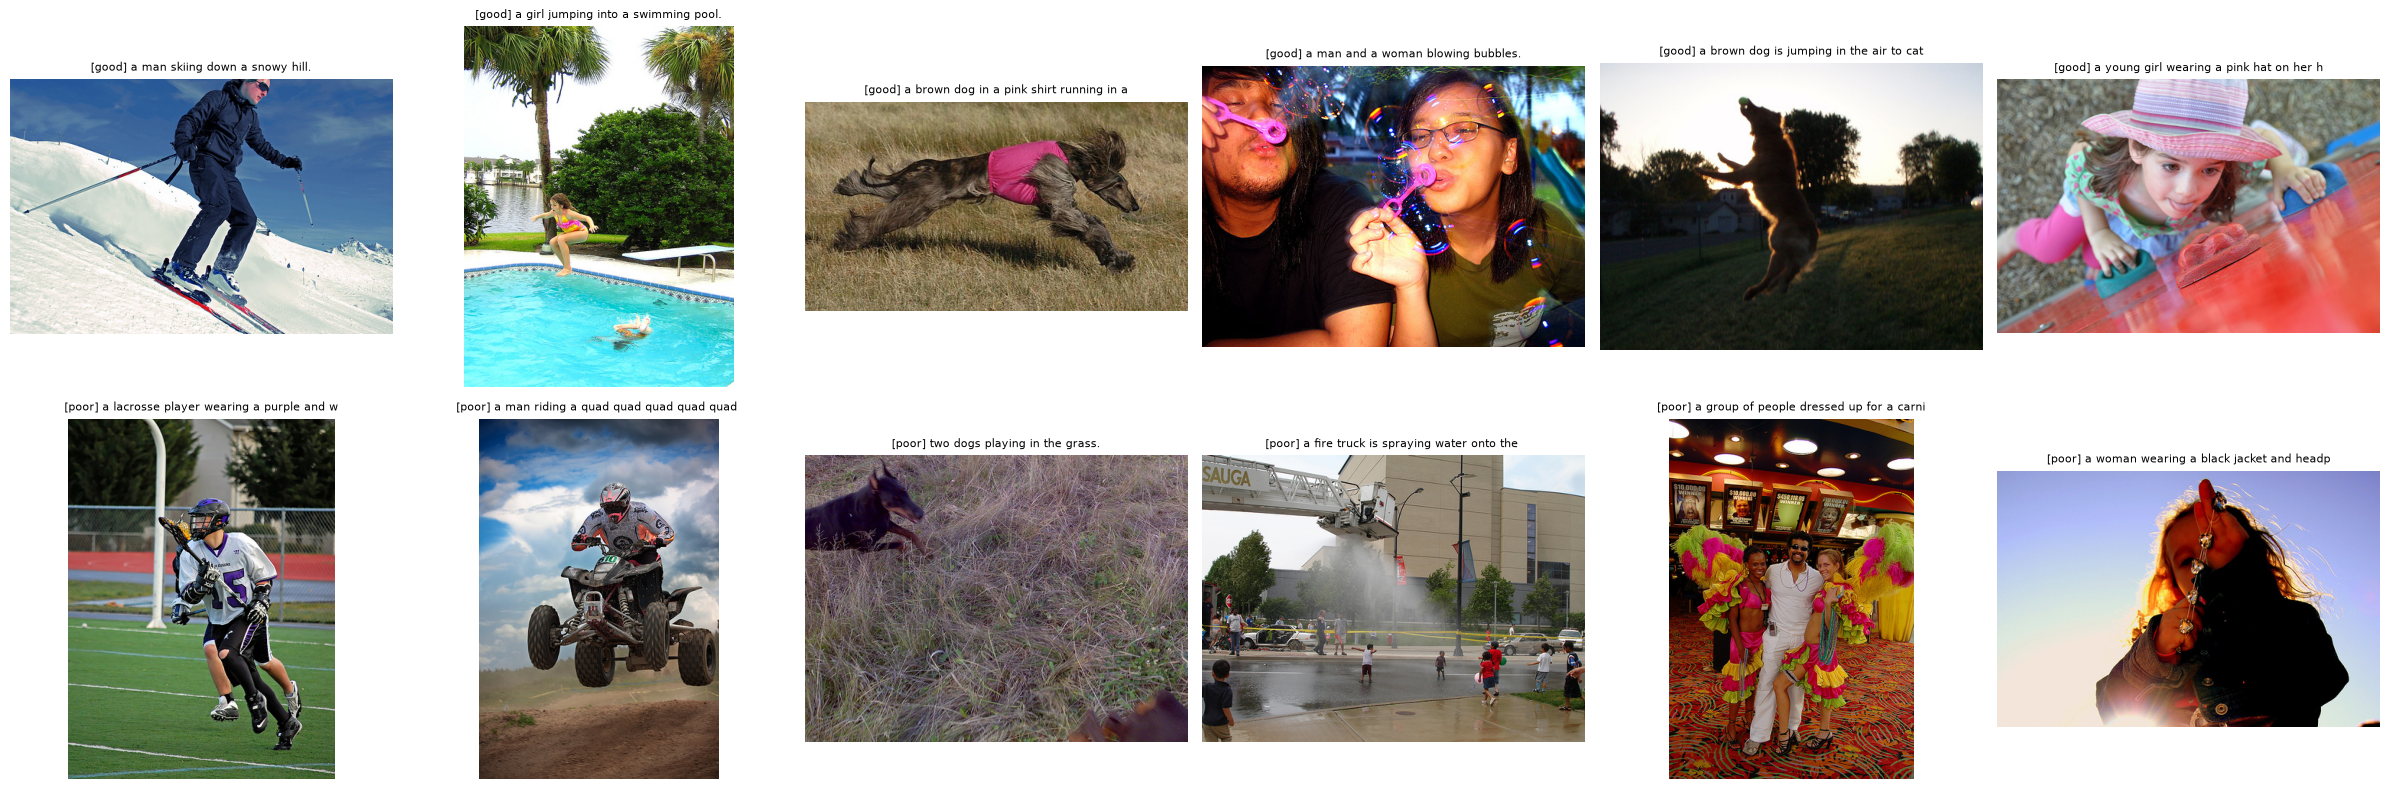

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for ax, (_, row) in zip(axes.flatten(), selected.iterrows()):
    image = Image.open(os.path.join(SAVE_DIR, row["image_name"]))
    ax.imshow(image)
    ax.set_title(f"[{row['quality_label']}] {row['generated_caption'][:40]}", fontsize=8, wrap=True)
    ax.axis("off")
plt.tight_layout()
plt.savefig("xai_examples_grid.png", dpi=150)
plt.show()